![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

### Task:

- Explore the crimes.csv dataset and use your findings to answer the following questions:

1. Which hour has the highest frequency of crimes? Store as an integer variable called peak_crime_hour.
2. Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)? Save as a string variable called peak_night_crime_location.
3. Identify the number of crimes committed against victims of different age groups. Save as a pandas Series called victim_ages, with age group labels "0-17", "18-25", "26-34", "35-44", "45-54", "55-64", and "65+" as the index and the frequency of crimes as the values.

Crime Hour
12    13663
18    10125
17     9964
20     9579
15     9393
19     9262
16     9224
14     8872
11     8787
00     8728
21     8701
22     8531
13     8474
10     8440
08     7523
23     7419
09     7092
01     5836
06     5621
07     5403
02     4726
03     3943
04     3238
05     3171
Name: count, dtype: int64


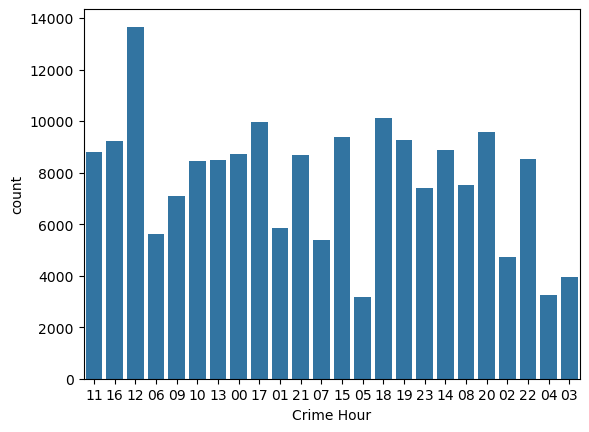

AREA NAME
Central        3312
Hollywood      2699
77th Street    2558
Southwest      2347
Southeast      2218
Newton         2142
Olympic        2137
Pacific        1916
Rampart        1860
N Hollywood    1855
Wilshire       1716
Northeast      1684
Van Nuys       1629
West Valley    1520
Topanga        1461
Mission        1453
Harbor         1384
West LA        1369
Devonshire     1348
Hollenbeck     1315
Foothill       1260
Name: count, dtype: int64
       DR_NO   Date Rptd    DATE OCC TIME OCC    AREA NAME        Crm Cd Desc  \
0  220314085  2022-07-22  2020-05-12     1110    Southwest  THEFT OF IDENTITY   
1  222013040  2022-08-06  2020-06-04     1620      Olympic  THEFT OF IDENTITY   
2  220614831  2022-08-18  2020-08-17     1200    Hollywood  THEFT OF IDENTITY   
3  231207725  2023-02-27  2020-01-27     0635  77th Street  THEFT OF IDENTITY   
4  220213256  2022-07-14  2020-07-14     0900      Rampart  THEFT OF IDENTITY   

   Vict Age Vict Sex Vict Descent Weapon Desc  Status Des

In [19]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes["Crime Hour"]=[time[0:2] for time in crimes["TIME OCC"]]
print(crimes['Crime Hour'].value_counts())
sns.countplot(x="Crime Hour", data=crimes)
plt.show()
night_crimes=crimes[np.logical_or(np.logical_and((crimes["TIME OCC"] >= "2200"),(crimes["TIME OCC"] <= "2359")),np.logical_and( (crimes["TIME OCC"] >= "0000"),(crimes["TIME OCC"] <= "0359")))]
peak_crime_hour=12
peak_night_crime_location="Central"
print(night_crimes["AREA NAME"].value_counts())
categories=["0-17","18-25","26-34","35-44","45-54","55-64","65+"]
conditions = [
    crimes["Vict Age"] <= 17,
    np.logical_and(crimes["Vict Age"] >= 18, crimes["Vict Age"] <= 25),
    np.logical_and(crimes["Vict Age"] >= 26, crimes["Vict Age"] <= 34),
    np.logical_and(crimes["Vict Age"] >= 35, crimes["Vict Age"] <= 44),
    np.logical_and(crimes["Vict Age"] >= 45, crimes["Vict Age"] <= 54),
    np.logical_and(crimes["Vict Age"] >= 55, crimes["Vict Age"] <= 64),
    crimes["Vict Age"] >= 65
]
crimes['Vict Age Cat'] = np.select(conditions,categories, default="")
print(crimes.head())
victim_ages=crimes["Vict Age Cat"].value_counts()
print(type(victim_ages))